In [33]:
!pip install kaggle


In [34]:
kaggle = '/content/sample_data/kaggle.json'

In [35]:
!mkdir -p ~/.kaggle
!cp /content/sample_data/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [36]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [37]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok= True) # Changed to os.makedirs

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [38]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [39]:
len(data_0)

2236

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [19]:
dataset_path = '/content/dataset'

data = []
labels = []

for label in range(10):
    folder_path = os.path.join(dataset_path, str(label))
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path).convert('L')
        img = img.resize((28, 28))
        img_array = np.array(img)
        data.append(img_array)
        labels.append(label)


In [20]:
X = np.array(data)
y = np.array(labels)

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (21555, 28, 28)
Shape y: (21555,)


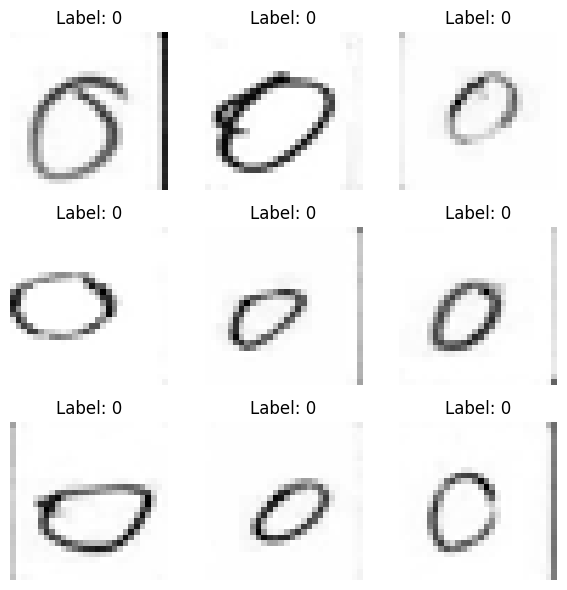

In [21]:
#visualisasi data
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [22]:
#normalisasi pixel
X = X.astype('float32') / 255.0

In [23]:
X = X.reshape(X.shape[0], 784)


In [24]:
encoder = LabelBinarizer()
y = encoder.fit_transform(y)


In [25]:
#split data train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (17244, 784)
X_test : (4311, 784)


In [26]:
print("Jumlah fitur input:", X_train.shape[1])


Jumlah fitur input: 784


In [27]:
#model ANN
model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [30]:
#TRAINING MODEL
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1016 - loss: 2.4544 - val_accuracy: 0.0989 - val_loss: 2.2975
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1198 - loss: 2.2942 - val_accuracy: 0.1424 - val_loss: 2.2546
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1629 - loss: 2.2296 - val_accuracy: 0.1960 - val_loss: 2.1400
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1905 - loss: 2.1692 - val_accuracy: 0.2496 - val_loss: 2.1098
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2030 - loss: 2.1456 - val_accuracy: 0.2308 - val_loss: 2.1037
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2104 - loss: 2.1254 - val_accuracy: 0.2575 - val_loss: 2.0354
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2043 - loss: 2.1294 - val_accuracy: 0.2415 - val_loss: 2.0517
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2115 - loss: 2.0998 - val_accu

In [31]:
#EVALUASI MODEL
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss :", loss)
print("Test Accuracy :", accuracy)


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3202 - loss: 1.9419
Test Loss : 1.9299856424331665
Test Accuracy : 0.32080724835395813


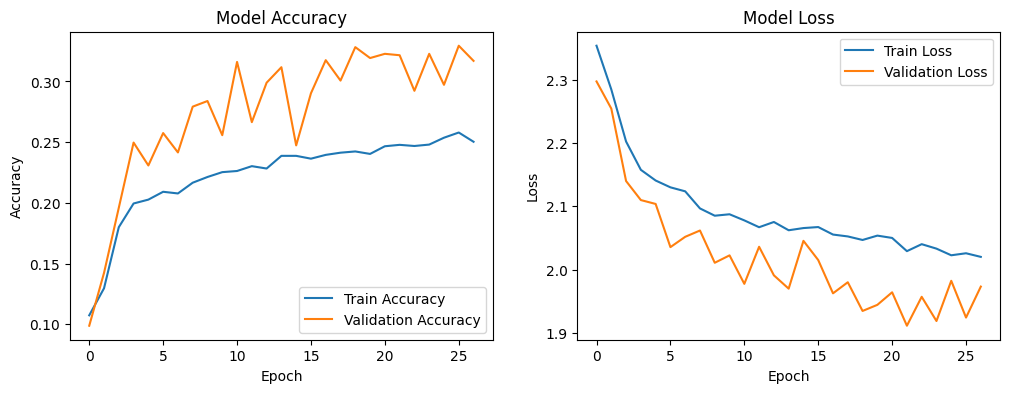

In [32]:
#VISUALISASI ACCURACY & LOSS
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
